In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analyzing the probabilities after fine tuning

<b> We had different tests for the fine tuning outputs: </b>

- using different div factor (25), final div factor (20000) and max_lr of 1e-5 instead of 3e-4
- using original div factors (50), final div factor (10000) and max lr of 1e-5
- using the original div factors and max lr of 1e-5 but changing epoch values to n_epochs_freeze: 40 and n_epochs_unfreeze: 60

# Most recent

In [3]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv")
df_final = pd.read_csv(file_path)
df_final

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.092565,0.154685,0.072600,0.173884,0.322611,0.183655,Human,0
1,1,0.413319,0.112904,0.113968,0.188249,0.064998,0.106563,Pig,0
2,2,0.492880,0.106734,0.093377,0.136344,0.080404,0.090262,Human,0
3,3,0.038249,0.136735,0.158560,0.180364,0.444808,0.041285,Human,0
4,4,0.099614,0.220222,0.065730,0.196319,0.233449,0.184666,Human,0
...,...,...,...,...,...,...,...,...,...
130,22,0.103008,0.164551,0.247137,0.027413,0.070135,0.387756,Chicken,4
131,23,0.015092,0.081642,0.101963,0.016482,0.541764,0.243057,Chicken,4
132,24,0.076392,0.624302,0.076234,0.035920,0.133933,0.053219,Human,4
133,25,0.025209,0.142712,0.335596,0.042261,0.386422,0.067800,Human,4


# Confusion Matrix

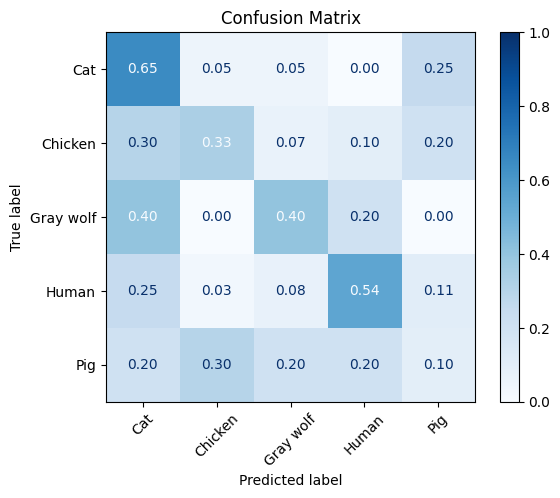

In [4]:
host_col = ['Cat', 'Chicken', 'Gray wolf', 'Human', 'Pig']
df_final['y_pred'] = df_final[host_col].idxmax(axis=1)

cm = confusion_matrix(df_final['y_true'], df_final['y_pred'], labels=host_col)
scale = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format = ".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix")
plt.show()



# Analysis

- cat, chicken, and human are predicted pretty well. Although, the model often mixes up almost everything for cat.
- For pig, it was not predicted correct even once.
- Wolf was correct on two occurrences, but cat was also predicted for wolf twice.
- Human was misclassified as Cat 15 times, which is a lot.
- The model seems to be weak, and this can be seen in the validation loss graph.

In [ ]:
file_path = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
three_epoch50 = pd.read_csv(file_path)
three_epoch50

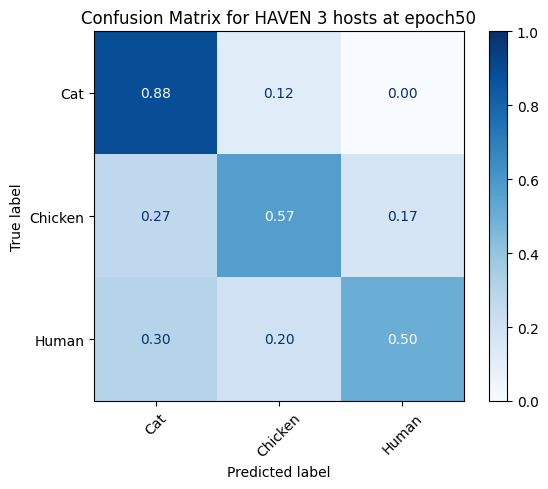

In [19]:
host_col = ['Cat', 'Chicken', 'Human']
three_epoch50['y_pred'] = three_epoch50[host_col].idxmax(axis=1)

cm = confusion_matrix(three_epoch50['y_true'], three_epoch50['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 3 hosts at epoch50")
plt.show()
#avg = 0.65

In [ ]:
file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
four_epoch50 = pd.read_csv(file)
four_epoch50

In [ ]:
host_col = ['Cat', 'Chicken', 'Human', 'Pig']
four_epoch50['y_pred'] = four_epoch50[host_col].idxmax(axis=1)

cm = confusion_matrix(four_epoch50['y_true'], four_epoch50['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for 4 hosts at epoch50")
plt.show()

#avg = 0.585

In [ ]:
file_path = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
three_epoch100 = pd.read_csv(file_path)
three_epoch100

In [ ]:
host_col = ['Cat', 'Chicken', 'Human']
three_epoch100['y_pred'] = three_epoch100[host_col].idxmax(axis=1)

cm = confusion_matrix(three_epoch100['y_true'], three_epoch100['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 3 hosts at epoch100")
plt.show()

#avg = 0.63666

In [ ]:
file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
four_epoch100 = pd.read_csv(file)
four_epoch100

In [ ]:
host_col = ['Cat', 'Chicken', 'Human', 'Pig']
four_epoch100['y_pred'] = four_epoch100[host_col].idxmax(axis=1)

cm = confusion_matrix(four_epoch100['y_true'], four_epoch100['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 4 hosts at epoch100")
plt.show()

#avg - 0.6125

# 3 hosts at epoch50 vs. traditional MLMs

In [ ]:
lr = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_lr_3hosts_lr_output.csv")
df_lr = pd.read_csv(lr)
df_lr



In [ ]:
host_col = ['Cat', 'Chicken', 'Human']
df_lr['y_pred'] = df_lr[host_col].idxmax(axis=1)

cm = confusion_matrix(df_lr['y_true'], df_lr['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for Logistic Regression")
figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/uniref50/lr_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()

#avg 0.73

In [ ]:
rf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_rf_3hosts_rf_output.csv")
df_rf = pd.read_csv(rf)
df_rf

In [ ]:
host_col = ['Cat', 'Chicken', 'Human']
df_rf['y_pred'] = df_rf[host_col].idxmax(axis=1)

cm = confusion_matrix(df_rf['y_true'], df_rf['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for Random Forest")

figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/uniref50/rf_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()
#avg 0.773

In [ ]:
svm = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_svm_3hosts_svm_output.csv")
df_svm = pd.read_csv(svm)
df_svm

In [ ]:
host_col = ['Cat', 'Chicken', 'Human']
df_svm['y_pred'] = df_svm[host_col].idxmax(axis=1)

cm = confusion_matrix(df_svm['y_true'], df_svm['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for SVM")
figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/uniref50/svm_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()

#avg 0.773